# PHY588 - Problem 1 - Hierarchical Bayesian Modeling

Hierarchical Bayesian Modeling of Contact Binary Eclipse Depths

We use eclipse depth data for contact binary systems observed by the Optical Gravitational Lensing Experiment (OGLE).

This hierarchical model estimates the population-level relationship between orbital period and eclipse depth in contact binaries.

The slope parameter $\beta$ quantifies whether eclipse depth systematically varies with orbital period.

The intercept $\alpha$ represents the expected eclipse depth at $\log P = 0$.

The parameter $\sigma$ captures intrinsic astrophysical scatter arising from:

- Mass-ratio differences,
- Temperature asymmetry,
- Starspot activity,
- Structural deviations from ideal Roche geometry.

Including both primary and secondary eclipse depths preserves astrophysical asymmetry rather than averaging away meaningful information.

Thus, the model provides inference on structural properties of contact binary systems at the population level.

## Load Data

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel("OGLE_binary_star survey.xlsx")

print("Number of systems:", len(data))
data.head()

# Ensure numeric columns are actually numeric (i had a problem with my data for some reason that i dont understand it would skip some colomnes)
data["Per"] = pd.to_numeric(data["Per"])
data["Depth"] = pd.to_numeric(data["Depth"])
data["Depth2"] = pd.to_numeric(data["Depth2"])

data = data.dropna(subset=["Per", "Depth", "Depth2"])

print(data.dtypes)

Number of systems: 100
Star       object
<Imag>    float64
<Vmag>    float64
Per       float64
T0        float64
Depth     float64
Depth2    float64
Type       object
dtype: object


In [5]:
P = data["Per"].to_numpy()
D1 = data["Depth"].to_numpy()
D2 = data["Depth2"].to_numpy()

logP = np.log(P)

print(D2.dtype)

float64


Hierarchical Model Specification

Define:
$$ x_i = \log P_i $$

Likelihood:
$$ D_{i,j} \sim \mathcal{N}(\mu_i, \sigma_{\mathrm{int}}) $$

where
$$ \mu_i = \alpha + \beta x_i $$

Priors
$$ \alpha \sim \mathcal{N}(0.45, 0.2) $$
$$ \beta \sim \mathcal{N}(0, 1) $$
$$ \sigma_{\mathrm{int}} \sim \text{HalfNormal}(0.3) $$

Justification of Priors

The hyperpriors were chosen to be weakly informative while remaining physically reasonable for contact binary systems.


1. Intercept Prior

$$
\alpha \sim \mathcal{N}(0.45, 0.2)
$$

The intercept represents the expected eclipse depth at $\log P = 0$.  
Observed eclipse depths are typically of order 0.1–0.8 mag, so a Normal prior with mean 0.45 and standard deviation 0.2 is centered in the physically plausible range while allowing reasonable flexibility.


2. Slope Prior

$$
\beta \sim \mathcal{N}(0, 10^2)
$$

The slope measures how eclipse depth varies with $\log P$.  
Since no strong prior knowledge exists about the direction or magnitude of this relationship, a symmetric Normal prior centered at zero is appropriate. The large variance ensures the data dominate inference.


3. Scatter Prior

$$
\sigma \sim \text{Half-Cauchy}(0, 5)
$$

The parameter $\sigma$ represents intrinsic scatter and must be positive.  
A Half-Cauchy prior is commonly used for scale parameters in hierarchical models because it is weakly informative and has heavy tails, preventing overly restrictive variance shrinkage.


Overall, these priors are weakly informative, physically reasonable, and allow the data to determine the posterior behavior.

Posterior Distribution

The likelihood is:
$$
\mathcal{L}(\alpha, \beta, \sigma_{\mathrm{int}})
=
\prod_{i=1}^{N}\prod_{j=1}^{2}
\frac{1}{\sqrt{2\pi}\sigma_{\mathrm{int}}}
\exp\left(
-\frac{(D_{i,j} - \alpha - \beta \log P_i)^2}{2\sigma_{\mathrm{int}}^2}
\right)
$$

The posterior is proportional to:
$$
p(\alpha, \beta, \sigma_{\mathrm{int}} | D)
\propto
\mathcal{L}(\alpha, \beta, \sigma_{\mathrm{int}})
p(\alpha)p(\beta)p(\sigma_{\mathrm{int}})
$$

**Why the Posterior Cannot Be Solved Analytically**

Although the likelihood is Gaussian, the posterior distribution does not admit a closed-form solution.

The full posterior is:

$$
p(\alpha, \beta, \sigma \mid D)
\propto
\left[
\prod_{i=1}^{N}
\prod_{j=1}^{2}
\mathcal{N}(D_{ij} \mid \alpha + \beta \log P_i, \sigma^2)
\right]
\times
p(\alpha)
\times
p(\beta)
\times
p(\sigma)
$$

While Gaussian likelihoods are conjugate to Gaussian priors on regression coefficients, the inclusion of:

- A Half-Cauchy prior on $\sigma$,
- A hierarchical structure with multiple observations per system,
- And the transformation $\log P_i$,

breaks conjugacy.

Specifically,

$$\sigma \sim \text{Half-Cauchy}(0, 5)$$

is not conjugate to the Gaussian likelihood.

Therefore, the posterior distribution

$$p(\alpha, \beta, \sigma \mid D)$$

does not have a closed-form analytic solution.

Numerical methods such as Markov Chain Monte Carlo (MCMC) are required.

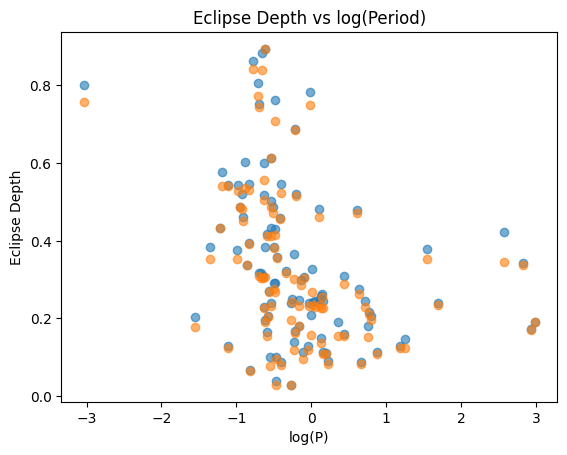

In [6]:

plt.scatter(logP, D1, alpha=0.6)
plt.scatter(logP, D2, alpha=0.6)
plt.xlabel('log(P)')
plt.ylabel('Eclipse Depth')
plt.title('Eclipse Depth vs log(Period)')
plt.show()